In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
import sys
import os
sys.path.append(os.path.abspath(".."))
from core_ntsa.generators import simulate_lorenz
from core_ntsa.noise_tools import add_white_noise, add_colored_noise
from core_ntsa.metrics import calculate_rosenstein_divergence, extract_lle_rosenstein

lorenz_data = simulate_lorenz(t_span=50.0, dt=0.01)
clean_x = lorenz_data[0]

x_white_noise = add_white_noise(clean_x, snr_db=40.0)
x_clored_noise = add_colored_noise(clean_x, color='pink', snr_db=30.0)

Hệ thống tự động thiết lập Cửa sổ Theiler (w) = 41 bước


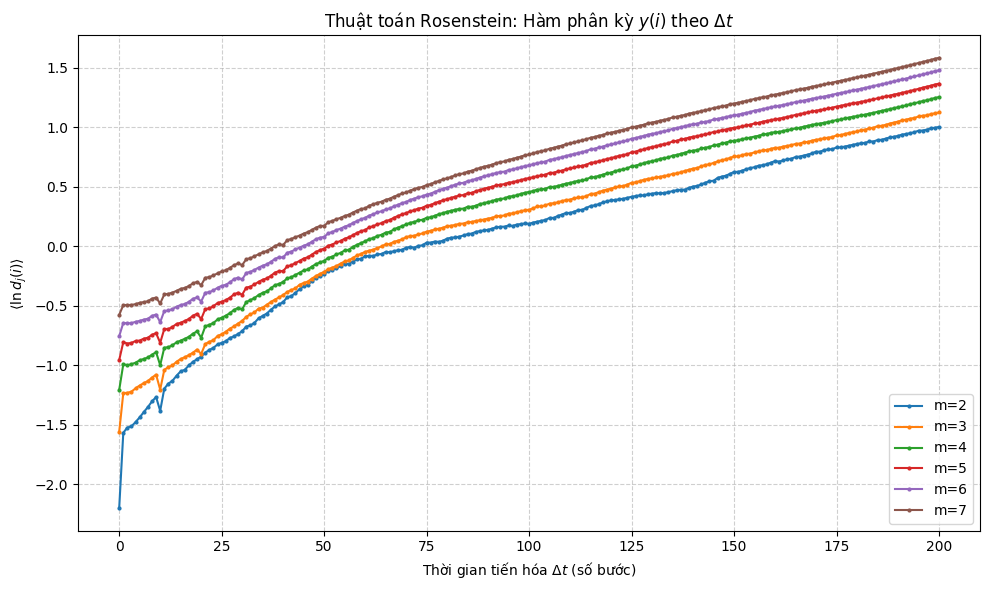

Kết quả trích xuất LLE (lambda_1):
----------------------------------------
m= 2: lambda_1 =  0.7766 (R^2 = 0.9960)
m= 3: lambda_1 =  0.8823 (R^2 = 0.9928)
m= 4: lambda_1 =  0.9410 (R^2 = 0.9906)
m= 5: lambda_1 =  0.9624 (R^2 = 0.9896)
m= 6: lambda_1 =  0.9759 (R^2 = 0.9899)
m= 7: lambda_1 =  0.9948 (R^2 = 0.9921)


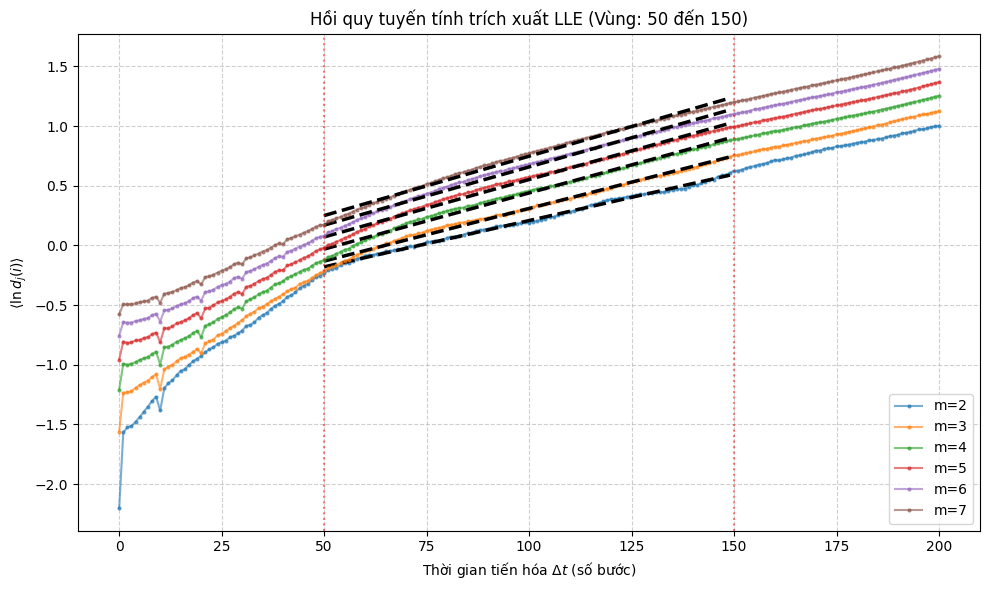

In [3]:
m_list_setup = [2, 3, 4, 5, 6, 7]
t_steps, y_results = calculate_rosenstein_divergence(
    signal=x_white_noise,
    tau=10,
    m_list=m_list_setup,
    t_min=0,
    t_max=200
)

lles = extract_lle_rosenstein(t_steps, y_results, dt=0.01, fit_start=50, fit_end=150)

Kết quả trích xuất LLE (lambda_1):
----------------------------------------
m= 2: lambda_1 =  1.8385 (R^2 = 0.9805)
m= 3: lambda_1 =  1.7573 (R^2 = 0.9966)
m= 4: lambda_1 =  1.6394 (R^2 = 0.9984)
m= 5: lambda_1 =  1.6466 (R^2 = 0.9978)
m= 6: lambda_1 =  1.6262 (R^2 = 0.9974)
m= 7: lambda_1 =  1.5339 (R^2 = 0.9969)


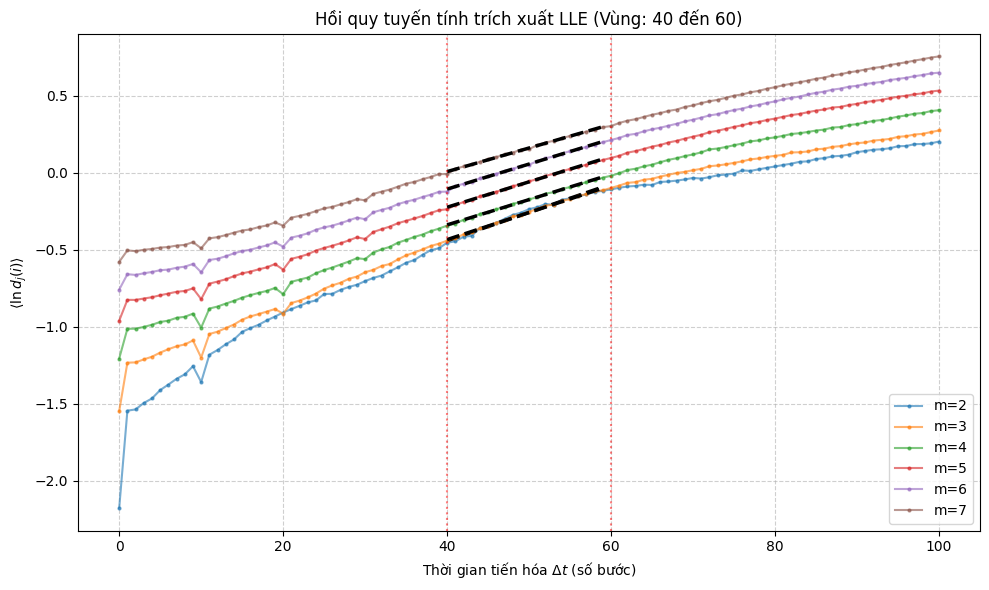

In [3]:
lles = extract_lle_rosenstein(t_steps, y_results, dt=0.01, fit_start=40, fit_end=60)

Hệ thống tự động thiết lập Cửa sổ Theiler (w) = 35 bước


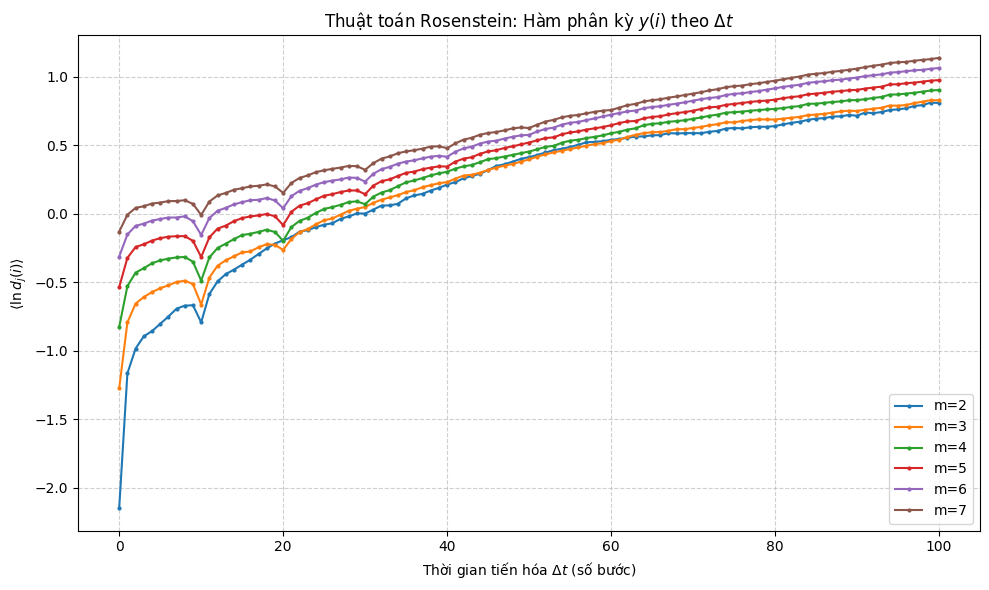

Kết quả trích xuất LLE (lambda_1):
----------------------------------------
m= 2: lambda_1 =  1.0202 (R^2 = 0.9107)
m= 3: lambda_1 =  1.1785 (R^2 = 0.9766)
m= 4: lambda_1 =  1.1798 (R^2 = 0.9880)
m= 5: lambda_1 =  1.1898 (R^2 = 0.9870)
m= 6: lambda_1 =  1.1973 (R^2 = 0.9880)
m= 7: lambda_1 =  1.1777 (R^2 = 0.9927)


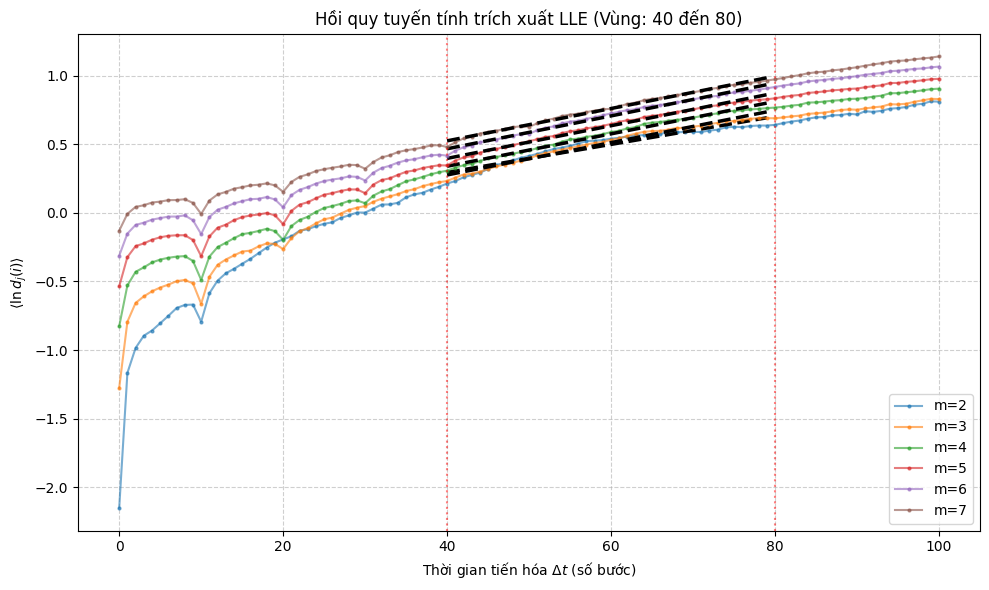

In [4]:
m_list_setup = [2, 3, 4, 5, 6, 7]
t_steps, y_results = calculate_rosenstein_divergence(
    signal=x_clored_noise,
    tau=10,
    m_list=m_list_setup,
    t_min=0,
    t_max=100
)

lles = extract_lle_rosenstein(t_steps, y_results, dt=0.01, fit_start=40, fit_end=80)

### TỔNG KẾT: ƯU ĐIỂM VÀ HẠN CHẾ CỦA THUẬT TOÁN ROSENSTEIN TRÊN THỰC NGHIỆM

Dưới đây là các điểm mấu chốt được đúc kết sau quá trình lập trình và kiểm thử thuật toán trên dữ liệu lý tưởng (Lorenz) lẫn dữ liệu nhiễu:

#### 🌟 Ưu điểm vượt trội (Pros)
* **Miễn nhiễm với "Sai số hướng":** Loại bỏ hoàn toàn quy trình tìm láng giềng thay thế (Replacement) như thuật toán Wolf, giúp triệt tiêu sai số góc và sự nhạy cảm với các tham số khoảng cách.
* **Hiện tượng "Song song tuyệt đối" (Robust Parallelism):** Tốc độ phân kỳ (độ dốc) duy trì tính nhất quán đáng kinh ngạc qua các chiều nhúng $m$ khác nhau, phản ánh đúng bản chất động lực học nội tại của hệ thống thay vì bị ảnh hưởng bởi không gian bên ngoài.
* **Sức đề kháng với Dữ liệu ngắn & Nhiễu:** Nhờ cơ chế lấy trung bình toàn cục $\langle \ln d_j(i) \rangle$, thuật toán có thể hoạt động ổn định trên các cửa sổ tín hiệu ngắn và tự động bù trừ các thăng giáng ngẫu nhiên do nhiễu đo lường.

#### ⚠️ Hạn chế và Hiện tượng cần lưu ý (Cons & Caveats)
* **Tính chủ quan cực đoan (Subjectivity):** Việc chọn ranh giới vùng tuyến tính (`fit_start`, `fit_end`) phụ thuộc rất lớn vào cảm tính. Sự xê dịch nhỏ của ranh giới trên đồ thị có thể bẻ gãy đường hồi quy và làm thay đổi hoàn toàn giá trị $\lambda_1$.
* **"Bóng ma" của Độ trễ thời gian (Periodic Dips):** Khi tín hiệu chứa nhiễu ngẫu nhiên, đồ thị phân kỳ sẽ xuất hiện các vết sụt giảm tuần hoàn tại chính xác các bước tiến hóa là bội số của $\tau$ (ví dụ: 10, 20, 30...).
* **Sự uốn cong của dữ liệu thực:** Hàm $y(i)$ của tín hiệu sinh lý thường có độ võng đi qua 3 giai đoạn (nhiễu cục bộ $\rightarrow$ phân kỳ mũ $\rightarrow$ bão hòa vật lý), hiếm khi là một đường thẳng hoàn hảo từ đầu đến cuối như lý thuyết.

#### 💡 Giải pháp Thực chiến (Practical Protocol)
* **Tiền xử lý:** Bắt buộc áp dụng các bộ lọc (Low-pass/Band-pass filter) để làm mượt đồ thị trước khi đưa vào không gian pha.
* **Cố định Giao thức (Fixed Window Protocol):** Chốt cứng một khung cửa sổ thời gian vật lý chung (ví dụ từ 0.5s đến 2.0s) cho mọi đoạn dữ liệu. Đừng đi tìm $\lambda_1$ tuyệt đối, hãy biến sự chênh lệch độ dốc trong cùng một khung ngắm thành Vector Đặc trưng phân loại.
* **Khép kín quy trình (Multi-view Feature Fusion):** Trích xuất độ dốc từ nhiều dải phân kỳ khác nhau và cung cấp cho mô hình phân loại để thuật toán tự động học được khoảng thời gian phản ánh tốt nhất sự thay đổi của trạng thái thần kinh.